# Titanic Survival Analysis
## Prepared By: Himanshi Sangani

### Import Libraries

In [157]:
import pandas as pd 
import numpy as np
import seaborn as sns 
import matplotlib.pyplot as plt

## Load Data 

In [158]:
df = pd.read_csv('Titanic_Survival.csv')
df.head(5)

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,2,Passenger_1,male,31.8,0,0,TKT100001,421.21,C130,S
1,2,0,1,Passenger_2,male,34.9,0,1,TKT100002,50.08,C32,S
2,3,0,3,Passenger_3,male,46.3,3,0,TKT100003,499.94,C75,S
3,4,1,2,Passenger_4,male,45.8,4,1,TKT100004,56.35,C25,S
4,5,0,3,Passenger_5,male,45.3,4,1,TKT100005,256.18,C120,S


## Data Understanding

In [159]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  50000 non-null  int64  
 1   Survived     50000 non-null  int64  
 2   Pclass       50000 non-null  int64  
 3   Name         50000 non-null  str    
 4   Sex          50000 non-null  str    
 5   Age          50000 non-null  float64
 6   SibSp        50000 non-null  int64  
 7   Parch        50000 non-null  int64  
 8   Ticket       50000 non-null  str    
 9   Fare         50000 non-null  float64
 10  Cabin        50000 non-null  str    
 11  Embarked     50000 non-null  str    
dtypes: float64(2), int64(5), str(5)
memory usage: 4.6 MB


In [160]:
df.dtypes

PassengerId      int64
Survived         int64
Pclass           int64
Name               str
Sex                str
Age            float64
SibSp            int64
Parch            int64
Ticket             str
Fare           float64
Cabin              str
Embarked           str
dtype: object

In [161]:
df.describe()

,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
count,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000
mean,25000.500000,0.488560,2.309880,40.049262,2.498720,2.006020,258.408149
std,14433.901067,0.499874,0.832003,23.012825,1.705983,1.417767,146.359929
min,1.000000,0.000000,1.000000,0.400000,0.000000,0.000000,4.010000
25%,12500.750000,0.000000,2.000000,20.000000,1.000000,1.000000,131.750000
50%,25000.500000,0.000000,3.000000,40.200000,2.000000,2.000000,258.460000
75%,37500.250000,1.000000,3.000000,60.100000,4.000000,3.000000,385.252500
max,50000.000000,1.000000,3.000000,80.000000,5.000000,4.000000,511.990000


## Data Cleaning

In [162]:
df.duplicated()

0        False
1        False
2        False
3        False
4        False
         ...  
49995    False
49996    False
49997    False
49998    False
49999    False
Length: 50000, dtype: bool

In [163]:
df.isnull().sum()

PassengerId    0
Survived       0
Pclass         0
Name           0
Sex            0
Age            0
SibSp          0
Parch          0
Ticket         0
Fare           0
Cabin          0
Embarked       0
dtype: int64

## Survival Rate

In [164]:
survivalRate = (df['Survived'].value_counts(normalize=True) * 100).round(2)
survivalRate

Survived
0    51.14
1    48.86
Name: proportion, dtype: float64

In [165]:
over_all_rate = (df['Survived'].mean()*100).round(2)
over_all_rate

np.float64(48.86)

In [166]:
survival = df.groupby("Survived")['PassengerId'].count()
survival

Survived
0    25572
1    24428
Name: PassengerId, dtype: int64

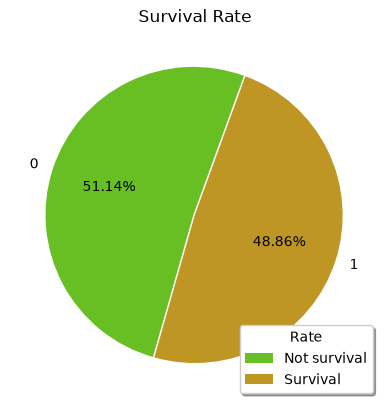

In [167]:
plt.pie(survival.values , labels=survival.index , autopct='%2.2f%%' , startangle=70 , explode=[0.01,0],colors=["#67bf24","#bf9624"])
plt.title("Survival Rate")
plt.legend(["Not survival" , "Survival"], shadow=True,
            fancybox=True ,title="Rate")
plt.show()

## Gender Survival

In [168]:
gender = (df.pivot_table(index='Sex',values='Survived',aggfunc='mean')*100).round(2)
gender

,Survived
Sex,
female,71.33
male,26.29


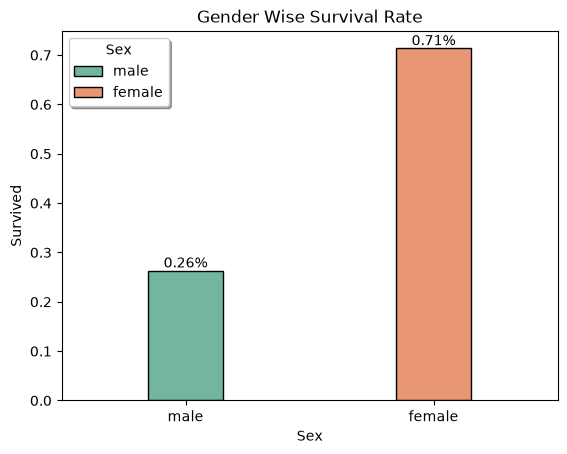

In [169]:
bar = sns.barplot(data=df , x="Sex" , y="Survived" , estimator='mean' , errorbar=None , width=0.3 , hue='Sex' , legend=True , 
                  palette='Set2',
                  edgecolor='black')

for i in bar.containers:
    plt.bar_label(i,fmt="%0.2f%%")

plt.title("Gender Wise Survival Rate")
plt.legend(title="Sex" , shadow=True)
plt.show()

## Passenger Class

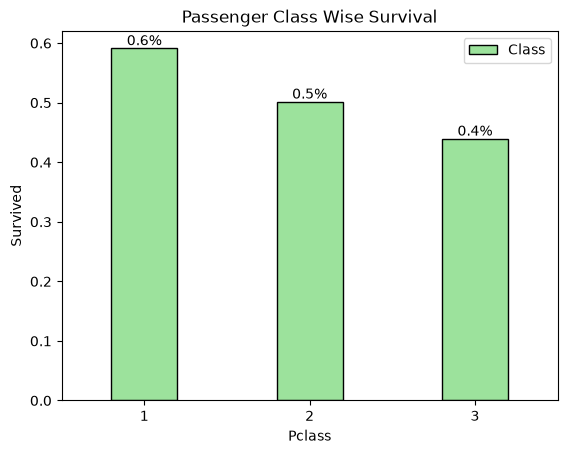

In [170]:
bar  = sns.barplot(data=df , x="Pclass" , y="Survived"  , 
                   errorbar=None  , color="lightgreen" , edgecolor="black",
                   width=0.4)

for i in bar.containers:
    plt.bar_label(i,fmt='%.1f%%')

plt.title("Passenger Class Wise Survival")
plt.legend(["Class"])
plt.show()

## Embarked

In [171]:
Embarked_total_count = df.groupby("Embarked")["PassengerId"].count()
Embarked_total_count

Embarked
C     9969
Q     5030
S    35001
Name: PassengerId, dtype: int64

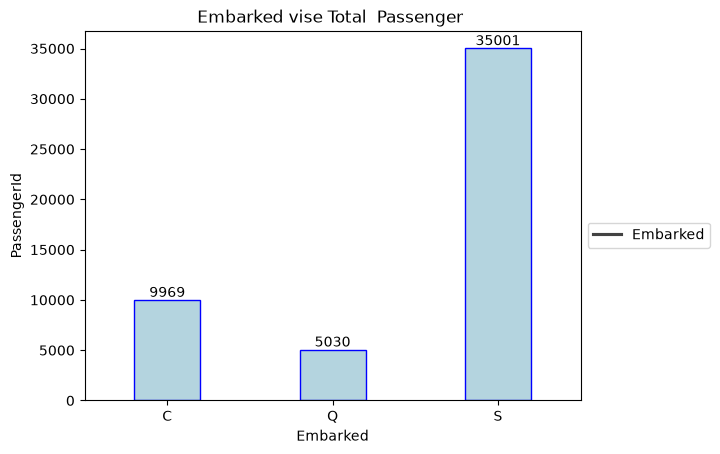

In [172]:
bar = sns.barplot(Embarked_total_count , width=0.4 , color="lightblue" , edgecolor="blue")

for i in bar.containers:
    plt.bar_label(i)

plt.title("Embarked vise Total  Passenger ")
plt.legend(["Embarked"],bbox_to_anchor=(1,0.5))
plt.show()

## Gender Embarked

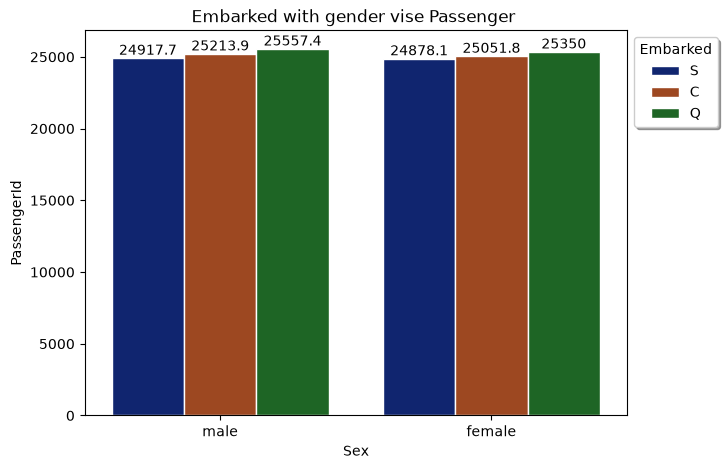

In [173]:
plt.figure(figsize=(7,5))
bar = sns.barplot(data=df , x="Sex" , y="PassengerId" , 
                  hue="Embarked" , errorbar=None , palette="dark" , edgecolor="white")


plt.title("Embarked with gender vise Passenger ")

for i in bar.containers:
    plt.bar_label(i)

plt.legend(bbox_to_anchor=(1,1) , shadow=True , 
           title="Embarked", fancybox=True)
plt.show()

## Fare with Class

In [174]:
fare = df.groupby(["Pclass","Sex"])["Fare"].mean().sort_values(ascending=False)
fare

Pclass  Sex   
1       male      260.016428
2       female    258.898057
3       female    258.329320
        male      258.067288
1       female    257.922231
2       male      257.739715
Name: Fare, dtype: float64

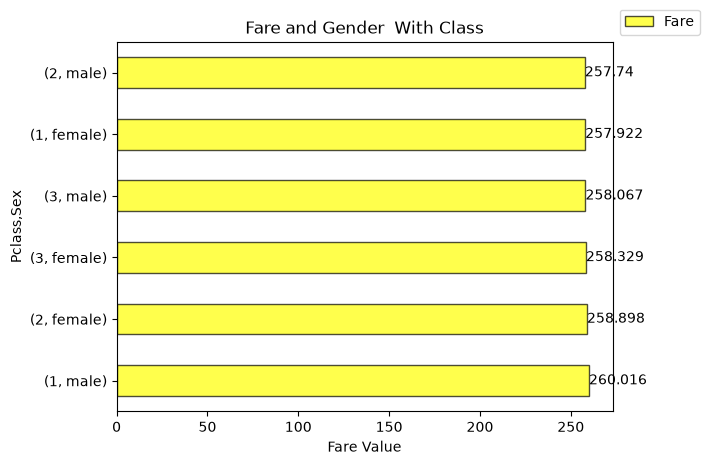

In [175]:
bar = fare.plot(kind="barh" , legend=True , color="yellow" , alpha=0.7 , edgecolor="black")

plt.xlabel("Fare Value")
plt.title("Fare and Gender  With Class")


for i in bar.containers:
    plt.bar_label(i)

plt.legend(bbox_to_anchor=(1,1))
plt.show()

## Age distribution and survival

In [176]:
df['Age'].max()

np.float64(80.0)

In [197]:
def Age_Groups(age):
   
    if age <= 12:
        return "Child"
    elif age <= 19:
        return "Teen"
    elif age <= 39:
        return "Adult"
    elif age <= 59:
        return "Middle Age"
    else:
        return "Senior"



   
    
df["Age_Group"] = df['Age'].apply(Age_Groups)


age_surval = df.groupby("Age_Group")["Survived"].mean().mul(100).round(2)
age_surval 


Age_Group
Adult         47.83
Child         54.77
Middle Age    47.39
Senior        47.59
Teen          49.66
Name: Survived, dtype: float64

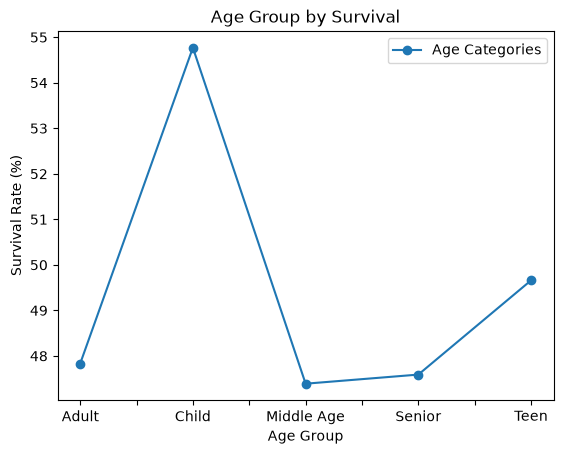

In [198]:
age_surval.plot(kind="line" , marker="o")

plt.xlabel("Age Group")
plt.ylabel("Survival Rate (%)")
plt.title("Age Group by Survival")
plt.legend(["Age Categories"])
plt.show()

## Correlation 

In [199]:
Correlation = df[["Survived","Pclass","Age","SibSp","Parch","Fare"]].corr(numeric_only=True)
Correlation

,Survived,Pclass,Age,SibSp,Parch,Fare
Survived,1.000000,-0.124204,-0.035061,-0.000111,-0.008637,-0.000172
Pclass,-0.124204,1.000000,-0.001693,0.000223,0.001335,-0.002038
Age,-0.035061,-0.001693,1.000000,0.011055,-0.001824,-0.004893
SibSp,-0.000111,0.000223,0.011055,1.000000,-0.000753,0.003179
Parch,-0.008637,0.001335,-0.001824,-0.000753,1.000000,0.002218
Fare,-0.000172,-0.002038,-0.004893,0.003179,0.002218,1.000000


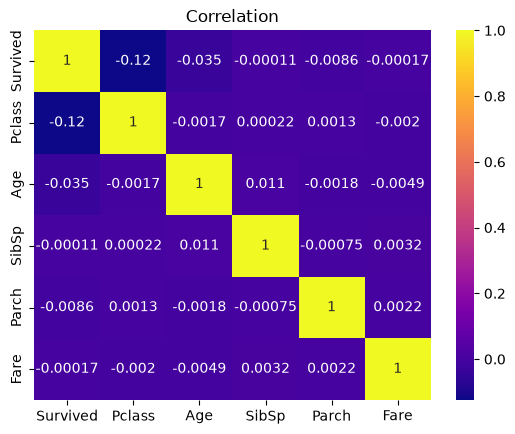

In [202]:
sns.heatmap(Correlation,annot=True,cmap="plasma")
plt.title("Correlation")
plt.show()

## Overall Insight
----
##### Approximately 48% of passengers survived, while 52% did not, indicating that more passengers lost their lives than were rescued.
##### Female passengers had a significantly higher survival rate than male passengers, suggesting that rescue efforts prioritized women.
##### First Class passengers experienced the highest survival rate, while Third Class passengers had the lowest survival rate.
##### Southampton (S) was the busiest embarkation port, with the largest number of passengers boarding the Titanic.
##### Higher ticket fares were generally associated with higher passenger classes and improved survival chances.
##### Survival rates varied across different age groups, indicating that age also influenced the likelihood of survival.
##### Correlation analysis showed that Passenger Class and Fare had stronger relationships with survival than other numerical variables such as Age, SibSp, and Parch.
##### Overall, the analysis indicates that Sex, Passenger Class (Pclass), Fare, Age, and Embarked were the key factors influencing passenger survival.